# Importing data and libraries

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from statsmodels.iolib.tableformatting import fmt2

In [6]:
data = load_penguins()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


# Visualizations

## Pandas

In [3]:
# Stack bars
# summary = data.groupby('species').agg({'bill_length_mm': 'mean', 'bill_depth_mm': 'mean', 'flipper_length_mm': 'mean'})
# summary.plot(kind='bar', stacked=True, ax=ax[4, 1], color=['red', 'blue', 'green'], width=0.5)
# ax[4, 1].set_title('Stack bars - OPTION 1')
# ax[4, 1].set_xticklabels(species, rotation=0)
# ax[4, 1].set_xlabel('Species')
# ax[4, 1].set_ylabel('Mean')

## Matplotlib

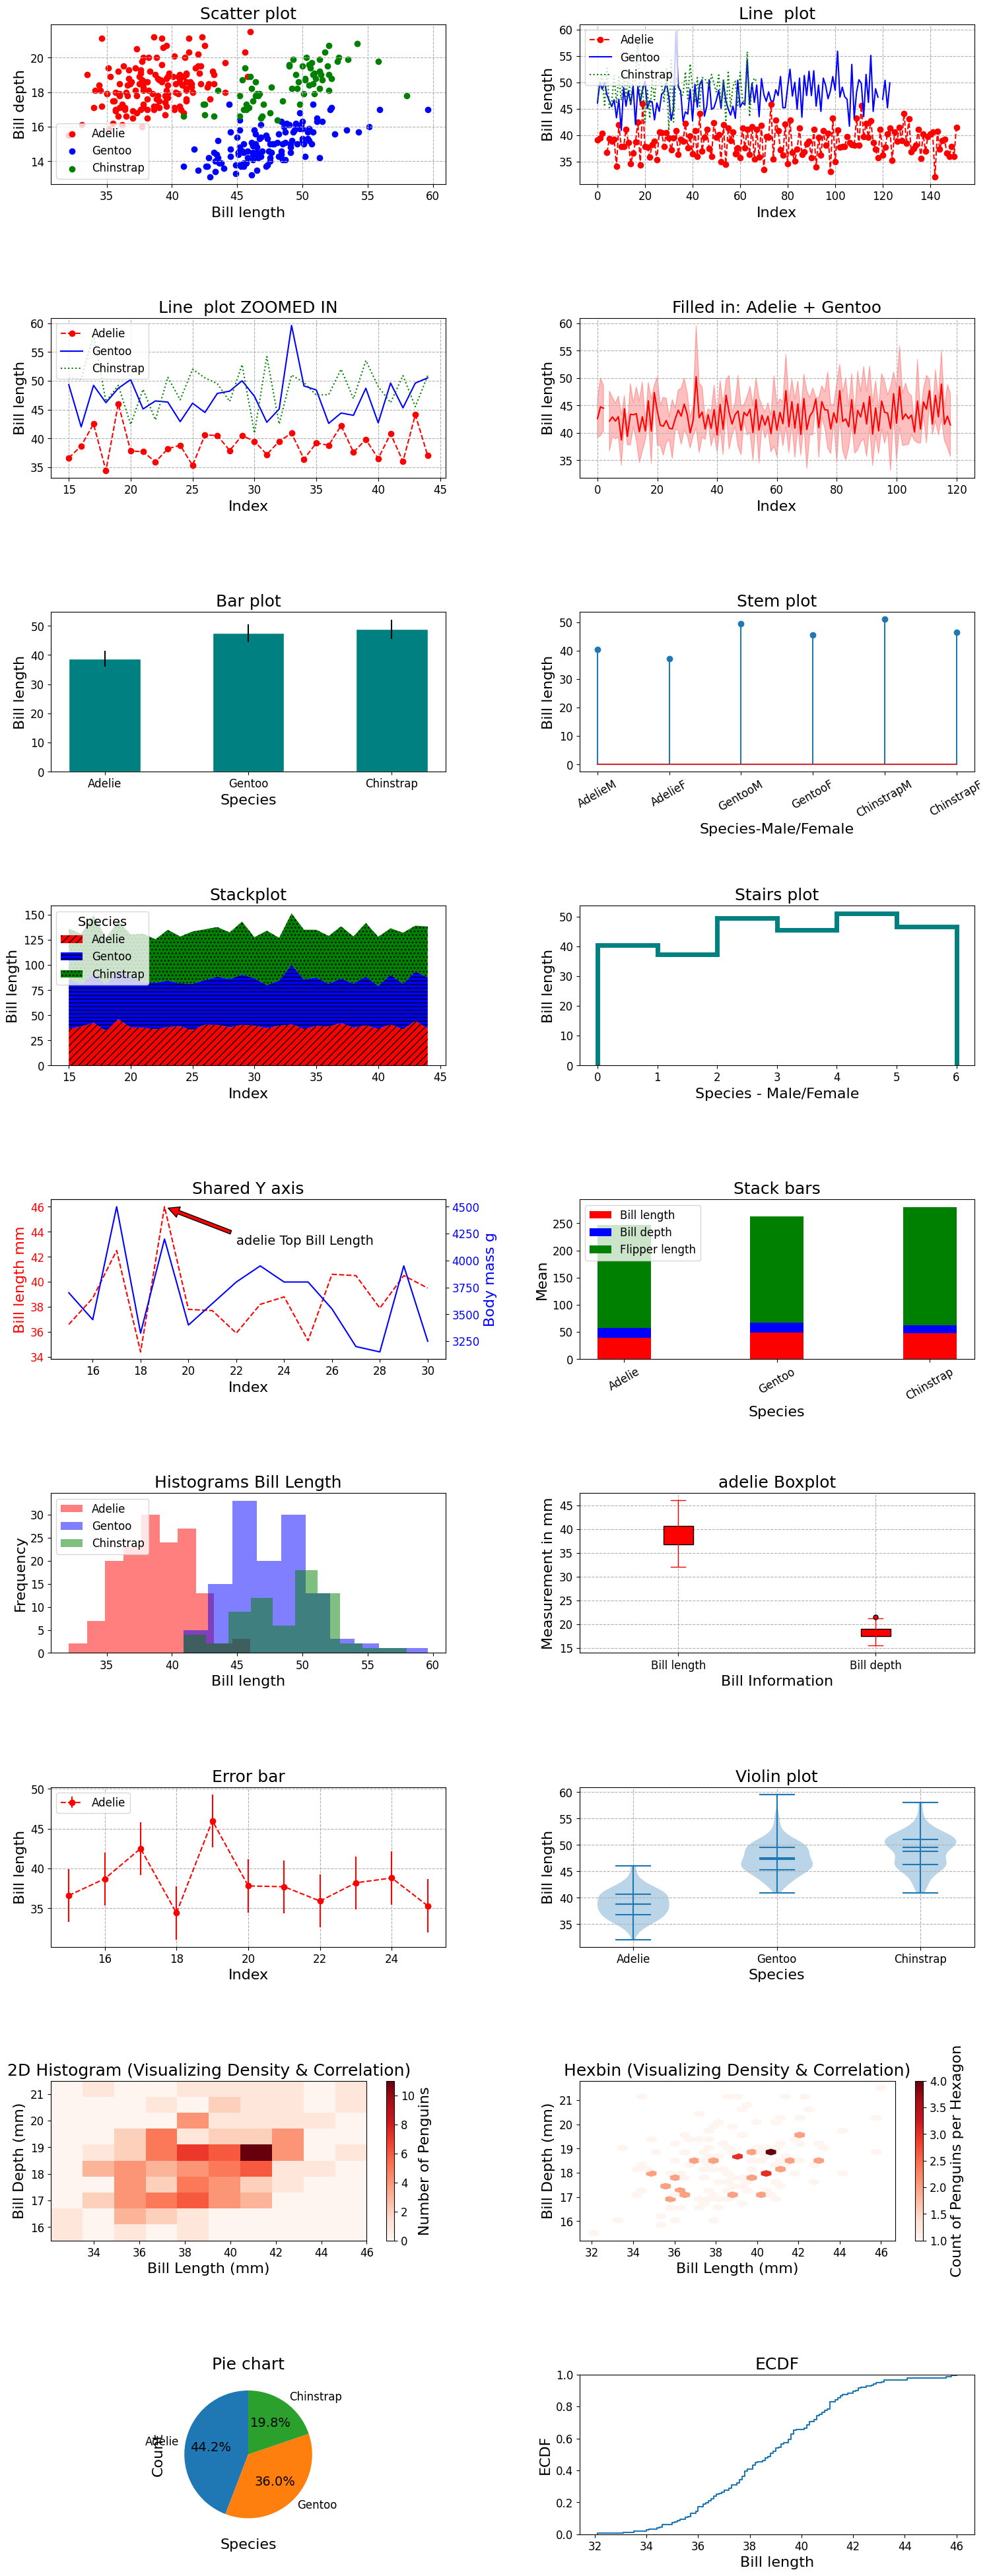

In [9]:
adelie = data[data.species == 'Adelie']
gentoo = data[data.species == 'Gentoo']
chinstrap = data[data.species == 'Chinstrap']

plt.rc('font', size=14)          # Controls default text sizes
plt.rc('axes', titlesize=18)     # Size of the subplot titles
plt.rc('axes', labelsize=16)     # Size of the x and y labels
plt.rc('xtick', labelsize=12)    # Size of the tick labels
plt.rc('ytick', labelsize=12)    # Size of the tick labels
plt.rc('legend', fontsize=12)    # Legend text size

figure, ax = plt.subplots(9, 2, figsize=(16, 40))

# Scatter plot
ax[0, 0].scatter(adelie.bill_length_mm, adelie.bill_depth_mm, color='red', label='Adelie')
ax[0, 0].scatter(gentoo.bill_length_mm, gentoo.bill_depth_mm, color='blue', label='Gentoo')
ax[0, 0].scatter(chinstrap.bill_length_mm, chinstrap.bill_depth_mm, color='green', label='Chinstrap')
ax[0, 0].legend(loc='lower left')
ax[0, 0].set_title('Scatter plot')
ax[0, 0].set_xlabel('Bill length')
ax[0, 0].set_ylabel('Bill depth')
ax[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
ax[0, 1].plot(np.arange(0, adelie.shape[0]), adelie['bill_length_mm'], color='red', label='Adelie', linestyle='--', marker='o')
ax[0, 1].plot(np.arange(0, gentoo.shape[0]), gentoo['bill_length_mm'], color='blue', label='Gentoo', linestyle='-')
ax[0, 1].plot(np.arange(0, chinstrap.shape[0]), chinstrap['bill_length_mm'], color='green', label='Chinstrap', linestyle=':')
ax[0, 1].legend(loc='upper left')
ax[0, 1].set_title('Line  plot')
ax[0, 1].set_xlabel('Index')
ax[0, 1].set_ylabel('Bill length')
ax[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Line plot ZOOMED IN
zoomed_in = np.arange(15, 45)
ax[1,0].plot(zoomed_in, adelie['bill_length_mm'].iloc[15:45], color='red', label='Adelie', linestyle='--', marker='o')
ax[1,0].plot(zoomed_in, gentoo['bill_length_mm'].iloc[15:45], color='blue', label='Gentoo', linestyle='-')
ax[1,0].plot(zoomed_in, chinstrap['bill_length_mm'].iloc[15:45], color='green', label='Chinstrap', linestyle=':')
ax[1,0].legend(loc='upper left')
ax[1,0].set_title('Line  plot ZOOMED IN')
ax[1,0].set_xlabel('Index')
ax[1,0].set_ylabel('Bill length')
ax[1,0].grid(True, linestyle='--', which='major', axis='both')

# Filled in
between = np.arange(0, 121)
adelie_120 = adelie['bill_length_mm'].iloc[0:121]
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121]
ax[1, 1].fill_between(between, adelie_120, gentoo_120, color='red', alpha=0.25)
ax[1, 1].plot(between, (adelie_120.values + gentoo_120.values)/2, color='red', linestyle='-')
ax[1, 1].set_title('Filled in: Adelie + Gentoo')
ax[1, 1].set_xlabel('Index')
ax[1, 1].set_ylabel('Bill length')
ax[1, 1].grid(True, linestyle='--', which='major', axis='both')

# Bar plot (X vs. Height)
species = ['Adelie', 'Gentoo', 'Chinstrap']
bill_length_mean = [adelie.bill_length_mm.mean(), gentoo.bill_length_mm.mean(), chinstrap.bill_length_mm.mean()]
bill_length_std = [adelie.bill_length_mm.std(), gentoo.bill_length_mm.std(), chinstrap.bill_length_mm.std()]
ax[2, 0].bar(species, bill_length_mean, color='teal', edgecolor='white', width=0.5, yerr=bill_length_std)
ax[2, 0].set_title('Bar plot')
ax[2, 0].set_xlabel('Species')
ax[2, 0].set_ylabel('Bill length')

# Stem plot (useful when there are too many categorical variables)
species_sex = ['AdelieM', 'AdelieF', 'GentooM', 'GentooF', 'ChinstrapM', 'ChinstrapF']
bill_length_sex = [adelie.query('sex == "male"').bill_length_mm.mean(), adelie.query('sex == "female"').bill_length_mm.mean(), gentoo.query('sex == "male"').bill_length_mm.mean(), gentoo.query('sex == "female"').bill_length_mm.mean(), chinstrap.query('sex == "male"').bill_length_mm.mean(), chinstrap.query('sex == "female"').bill_length_mm.mean()]
ax[2, 1].stem(species_sex, bill_length_sex)
ax[2, 1].set_title('Stem plot')
ax[2, 1].set_xticks(range(len(species_sex)))
ax[2, 1].set_xticklabels(species_sex, rotation=30)
ax[2, 1].set_xlabel('Species-Male/Female')
ax[2, 1].set_ylabel('Bill length')

# Stack plot
bill_zoom_matrix = np.vstack([adelie['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45], chinstrap['bill_length_mm'].iloc[15:45]])
ax[3, 0].stackplot(zoomed_in, bill_zoom_matrix, labels=['Adelie', 'Gentoo', 'Chinstrap'], baseline='zero', colors=['red', 'blue', 'green'], hatch=['///', '---', '...'])
ax[3, 0].set_title('Stackplot')
ax[3, 0].set_xlabel('Index')
ax[3, 0].set_ylabel('Bill length')
ax[3, 0].legend(loc='upper left', title='Species')

# Stairs
ax[3, 1].stairs(bill_length_sex, linewidth=5, fill=False, color='teal', orientation='vertical')
ax[3, 1].set_title('Stairs plot')
ax[3, 1].set_xlabel('Species - Male/Female')
ax[3, 1].set_ylabel('Bill length')

# Shared Y axis
zoomed_in = np.arange(15, 31)
ax[4, 0].plot(zoomed_in, adelie['bill_length_mm'].iloc[15:31], color='red', linestyle='--')
ax[4, 0].set_title('Shared Y axis')
ax[4, 0].set_xlabel('Index')
ax[4, 0].set_ylabel('Bill length mm', color='red')
ax[4, 0].tick_params(axis='y', labelcolor='red')
ax[4, 0].annotate('adelie Top Bill Length', xy=(19, 46), xytext=(22, 43), arrowprops=dict(facecolor='red', shrink=0.05))

ax2 = ax[4, 0].twinx()
ax2.plot(zoomed_in, adelie['body_mass_g'].iloc[15:31], color='blue', linestyle='-')
ax2.set_ylabel('Body mass g', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Stack bars
summary = data.groupby('species').agg({'bill_length_mm': 'mean', 'bill_depth_mm': 'mean', 'flipper_length_mm': 'mean'})
ax[4, 1].bar(summary.index, summary['bill_length_mm'], width=0.35, label='Bill length', color='red')
ax[4, 1].bar(summary.index, summary['bill_depth_mm'], bottom=summary['bill_length_mm'], width=0.35, label='Bill depth', color='blue')
ax[4, 1].bar(summary.index, summary['flipper_length_mm'], bottom=summary['bill_length_mm'] + summary['bill_depth_mm'], width=0.35, label='Flipper length', color='green')
ax[4, 1].legend(loc='upper left')
ax[4, 1].set_title('Stack bars')
ax[4, 1].set_xticks(range(len(species)))
ax[4, 1].set_xticklabels(species, rotation=30)
ax[4, 1].set_xlabel('Species')
ax[4, 1].set_ylabel('Mean')

# Histograms
ax[5, 0].hist(adelie['bill_length_mm'], bins=10, color='red', alpha=0.5, label='Adelie', histtype='bar')
ax[5, 0].hist(gentoo['bill_length_mm'], bins=10, color='blue', alpha=0.5, label='Gentoo', histtype='bar')
ax[5, 0].hist(chinstrap['bill_length_mm'], bins=10, color='green', alpha=0.5, label='Chinstrap', histtype='bar')
ax[5, 0].legend(loc='upper left')
ax[5, 0].set_title('Histograms Bill Length')
ax[5, 0].set_xlabel('Bill length')
ax[5, 0].set_ylabel('Frequency')

# Boxplot
ax[5, 1].boxplot([adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill()], tick_labels=['Bill length', 'Bill depth'], patch_artist=True, boxprops=dict(facecolor='red'), whiskerprops=dict(color='red'), flierprops=dict(marker='o', markerfacecolor='red', markersize=5), medianprops=dict(color='red'), capprops=dict(color='red'))
ax[5, 1].set_title('adelie Boxplot')
ax[5, 1].set_xlabel('Bill Information')
ax[5, 1].set_ylabel('Measurement in mm')
ax[5, 1].grid(True, linestyle='--', which='major', axis='both')

# Error bar
ax[6,0].errorbar(np.arange(15, 26), adelie['bill_length_mm'].iloc[15:26], yerr=adelie['bill_length_mm'].iloc[15:26].std(), color='red', linestyle='--', marker='o', label='Adelie')
ax[6,0].legend(loc='upper left')
ax[6,0].set_title('Error bar')
ax[6,0].set_xlabel('Index')
ax[6,0].set_ylabel('Bill length')
ax[6,0].grid(True, linestyle='--', which='major', axis='both')

# Violin plot
quantiles = [[0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1]]
ax[6, 1].violinplot([adelie['bill_length_mm'].ffill(), gentoo['bill_length_mm'].ffill(), chinstrap['bill_length_mm'].ffill()], showmeans=True, showmedians=True, showextrema=True, quantiles=quantiles)
ax[6, 1].set_title('Violin plot')
ax[6, 1].set_xlabel('Species')
ax[6, 1].set_ylabel('Bill length')
ax[6, 1].grid(True, linestyle='--', which='major', axis='both')
ax[6, 1].set_xticks([1, 2, 3])
ax[6, 1].set_xticklabels(['Adelie', 'Gentoo', 'Chinstrap'])

# Histogram 2D
counts, xedges, yedges, im = ax[7, 0].hist2d(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
figure.colorbar(im, ax=ax[7, 0], label='Number of Penguins')
ax[7, 0].set_title('2D Histogram (Visualizing Density & Correlation)')
ax[7, 0].set_xlabel('Bill Length (mm)')
ax[7, 0].set_ylabel('Bill Depth (mm)')

# Hexbin
# counts, xedges, yedges, im = ax[7, 1].hexbin(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
# figure.colorbar(im, ax=ax[7, 1], label='Number of Penguins')
hb = ax[7, 1].hexbin(adelie['bill_length_mm'].ffill(), adelie['bill_depth_mm'].ffill(), gridsize=30, cmap='Reds', mincnt=1)
figure.colorbar(hb, ax=ax[7,1], label='Count of Penguins per Hexagon')
ax[7, 1].set_title('Hexbin (Visualizing Density & Correlation)')
ax[7, 1].set_xlabel('Bill Length (mm)')
ax[7, 1].set_ylabel('Bill Depth (mm)')

# Pie chart
species_count = data.species.value_counts()
ax[8, 0].pie(species_count, labels=species_count.index, autopct='%1.1f%%', startangle=90)
ax[8, 0].set_title('Pie chart')
ax[8, 0].set_xlabel('Species')
ax[8, 0].set_ylabel('Count')

# ECDF
ax[8, 1].ecdf(adelie['bill_length_mm'].ffill(), label='Adelie')
ax[8, 1].set_title('ECDF')
ax[8, 1].set_xlabel('Bill length')
ax[8, 1].set_ylabel('ECDF')

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

## Seaborn

### Ax based

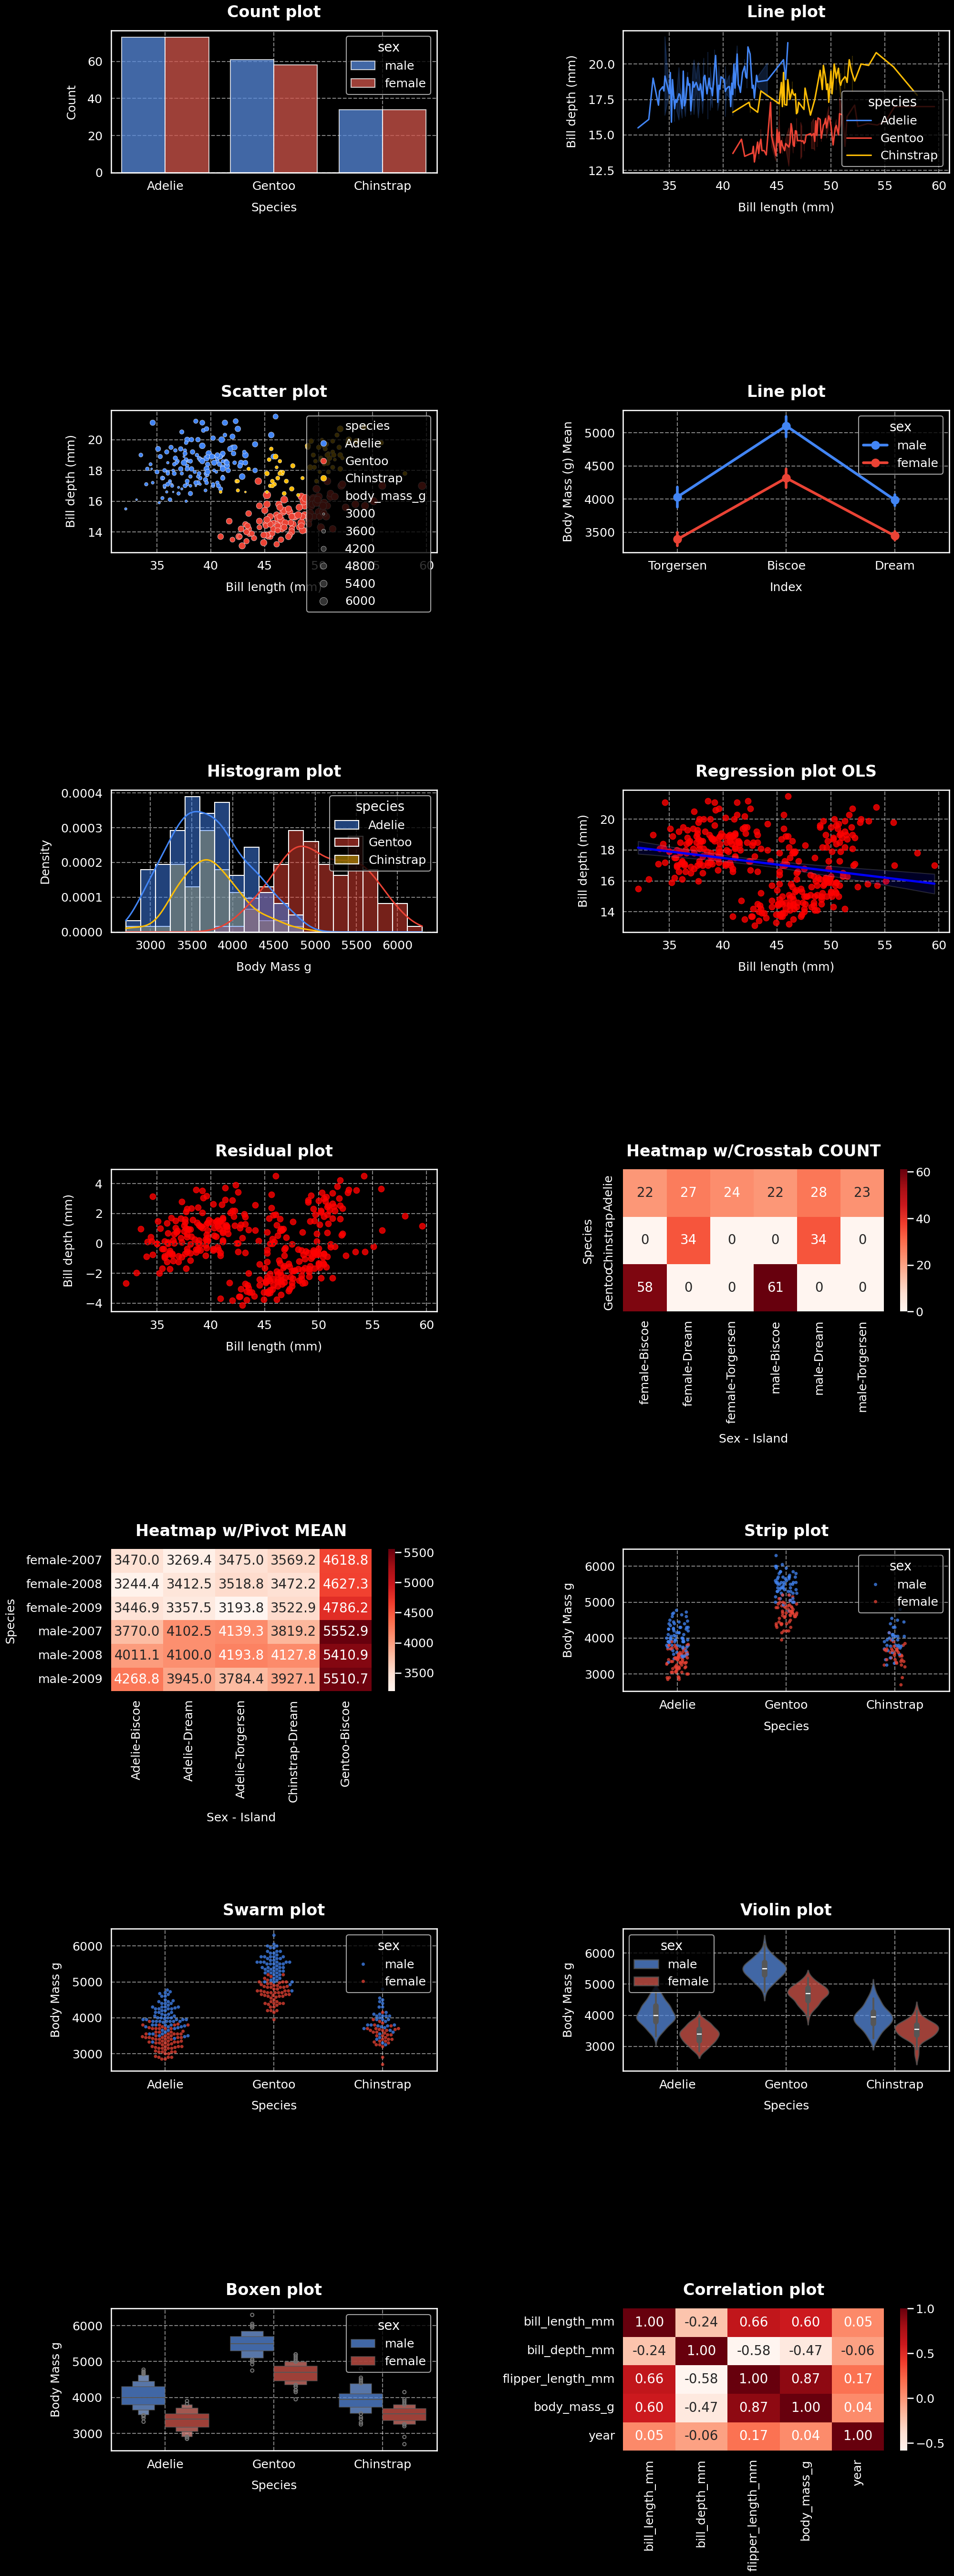

In [10]:
sns.set_context("talk", font_scale=1.1)

# 2. THEME FIX: Set dark style using Seaborn so both Matplotlib and Seaborn styles align perfectly
sns.set_style("darkgrid", {
    "background.color": "#111111",
    "axes.facecolor": "#1c1c1c",
    "grid.color": "#444444"
})
plt.style.use('dark_background')

figure, axes = plt.subplots(7, 2, figsize=(22, 56))

plt.style.use('dark_background')
# sns.set_theme(style="darkgrid")
google_colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]
google_three = ["#4285F4", "#EA4335", "#FBBC05"]
sns.set_palette(google_colors)

# Count plot
sns.countplot(data=data, x="species", ax=axes[0, 0], hue='sex', alpha=0.75)
axes[0, 0].set_title('Count plot', pad=20, fontsize=24, fontweight='bold')
axes[0, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[0, 0].set_ylabel('Count', labelpad=15, fontsize=18)
axes[0, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Line plot
sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0, 1], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], errorbar='sd')
axes[0, 1].set_title('Line plot', pad=20, fontsize=24, fontweight='bold')
axes[0, 1].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[0, 1].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[0, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Scatter plot
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', ax=axes[1, 0], palette=google_three, hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], size='body_mass_g', sizes=(1, 150))
axes[1, 0].set_title('Scatter plot', pad=20, fontsize=24, fontweight='bold')
axes[1, 0].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[1, 0].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[1, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Line plot
sns.pointplot(data=data, x='island', y="body_mass_g", hue="sex", ax=axes[1, 1], estimator='mean')
axes[1, 1].set_title('Line plot', pad=20, fontsize=24, fontweight='bold')
axes[1, 1].set_xlabel('Index', labelpad=15, fontsize=18)
axes[1, 1].set_ylabel('Body Mass (g) Mean', labelpad=15, fontsize=18)
axes[1, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Histogram
sns.histplot(data=data, x='body_mass_g', hue='species', palette=google_three, kde=True, bins=20, ax=axes[2, 0], legend=True, stat='density')
axes[2, 0].set_title('Histogram plot', pad=20, fontsize=24, fontweight='bold')
axes[2, 0].set_xlabel('Body Mass g', labelpad=15, fontsize=18)
axes[2, 0].set_ylabel('Density', labelpad=15, fontsize=18)
axes[2, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Regression plot
sns.regplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[2, 1], color='red', scatter=True, line_kws={'color': 'blue'}, order=1)
axes[2, 1].set_title('Regression plot OLS', pad=20, fontsize=24, fontweight='bold')
axes[2, 1].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[2, 1].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[2, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Residual plot
sns.residplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[3, 0], color='red')
axes[3, 0].set_title('Residual plot', pad=20, fontsize=24, fontweight='bold')
axes[3, 0].set_xlabel('Bill length (mm)', labelpad=15, fontsize=18)
axes[3, 0].set_ylabel('Bill depth (mm)', labelpad=15, fontsize=18)
axes[3, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Heatmap OPTION Crosstab
cross_data = pd.crosstab(data.species, [data.sex, data.island])
sns.heatmap(cross_data, annot=True, fmt='d', cmap='Reds', ax=axes[3, 1])
axes[3, 1].set_title('Heatmap w/Crosstab COUNT', pad=20, fontsize=24, fontweight='bold')
axes[3, 1].set_ylabel('Species', labelpad=15, fontsize=18)
axes[3, 1].set_xlabel('Sex - Island', labelpad=15, fontsize=18)

#  Heatmap OPTION Pivot table
pivot_table = pd.pivot_table(data=data, index=['sex', 'year'], columns=['species', 'island'], values='body_mass_g', aggfunc='mean').round(1).fillna(0)
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='Reds', ax=axes[4, 0])
axes[4, 0].set_title('Heatmap w/Pivot MEAN', pad=20, fontsize=24, fontweight='bold')
axes[4, 0].set_ylabel('Species', labelpad=15, fontsize=18)
axes[4, 0].set_xlabel('Sex - Island', labelpad=15, fontsize=18)

# Strip plot
sns.stripplot(data=data, x="species", y='body_mass_g', ax=axes[4, 1], hue='sex', alpha=0.75, )
axes[4, 1].set_title('Strip plot', pad=20, fontsize=24, fontweight='bold')
axes[4, 1].set_xlabel('Species', labelpad=15, fontsize=18)
axes[4, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[4, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Swarm plot
sns.swarmplot(data=data, x="species", y='body_mass_g', ax=axes[5, 0], hue='sex', alpha=0.75)
axes[5, 0].set_title('Swarm plot', pad=20, fontsize=24, fontweight='bold')
axes[5, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[5, 0].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[5, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Violin plot
sns.violinplot(data=data, x="species", y='body_mass_g', ax=axes[5, 1], hue='sex', alpha=0.75)
axes[5, 1].set_title('Violin plot', pad=20, fontsize=24, fontweight='bold')
axes[5, 1].set_xlabel('Species', labelpad=15, fontsize=18)
axes[5, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[5, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Boxen plot
sns.boxenplot(data=data, x="species", y='body_mass_g', ax=axes[6, 0], hue='sex', alpha=0.75)
axes[6, 0].set_title('Boxen plot', pad=20, fontsize=24, fontweight='bold')
axes[6, 0].set_xlabel('Species', labelpad=15, fontsize=18)
axes[6, 0].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[6, 0].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

# Correlation plot
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Reds', ax=axes[6, 1])
axes[6, 1].set_title('Correlation plot', pad=20, fontsize=24, fontweight='bold')
# axes[6, 1].set_xlabel('Species', labelpad=15, fontsize=18)
# axes[6, 1].set_ylabel('Body Mass g', labelpad=15, fontsize=18)
axes[6, 1].grid(True, linestyle='--', which='major', axis='both', alpha=0.5)

plt.tight_layout(pad=4.0, h_pad=6.0, w_pad=5.0)
plt.show()

### figureure based

#### Rel plot

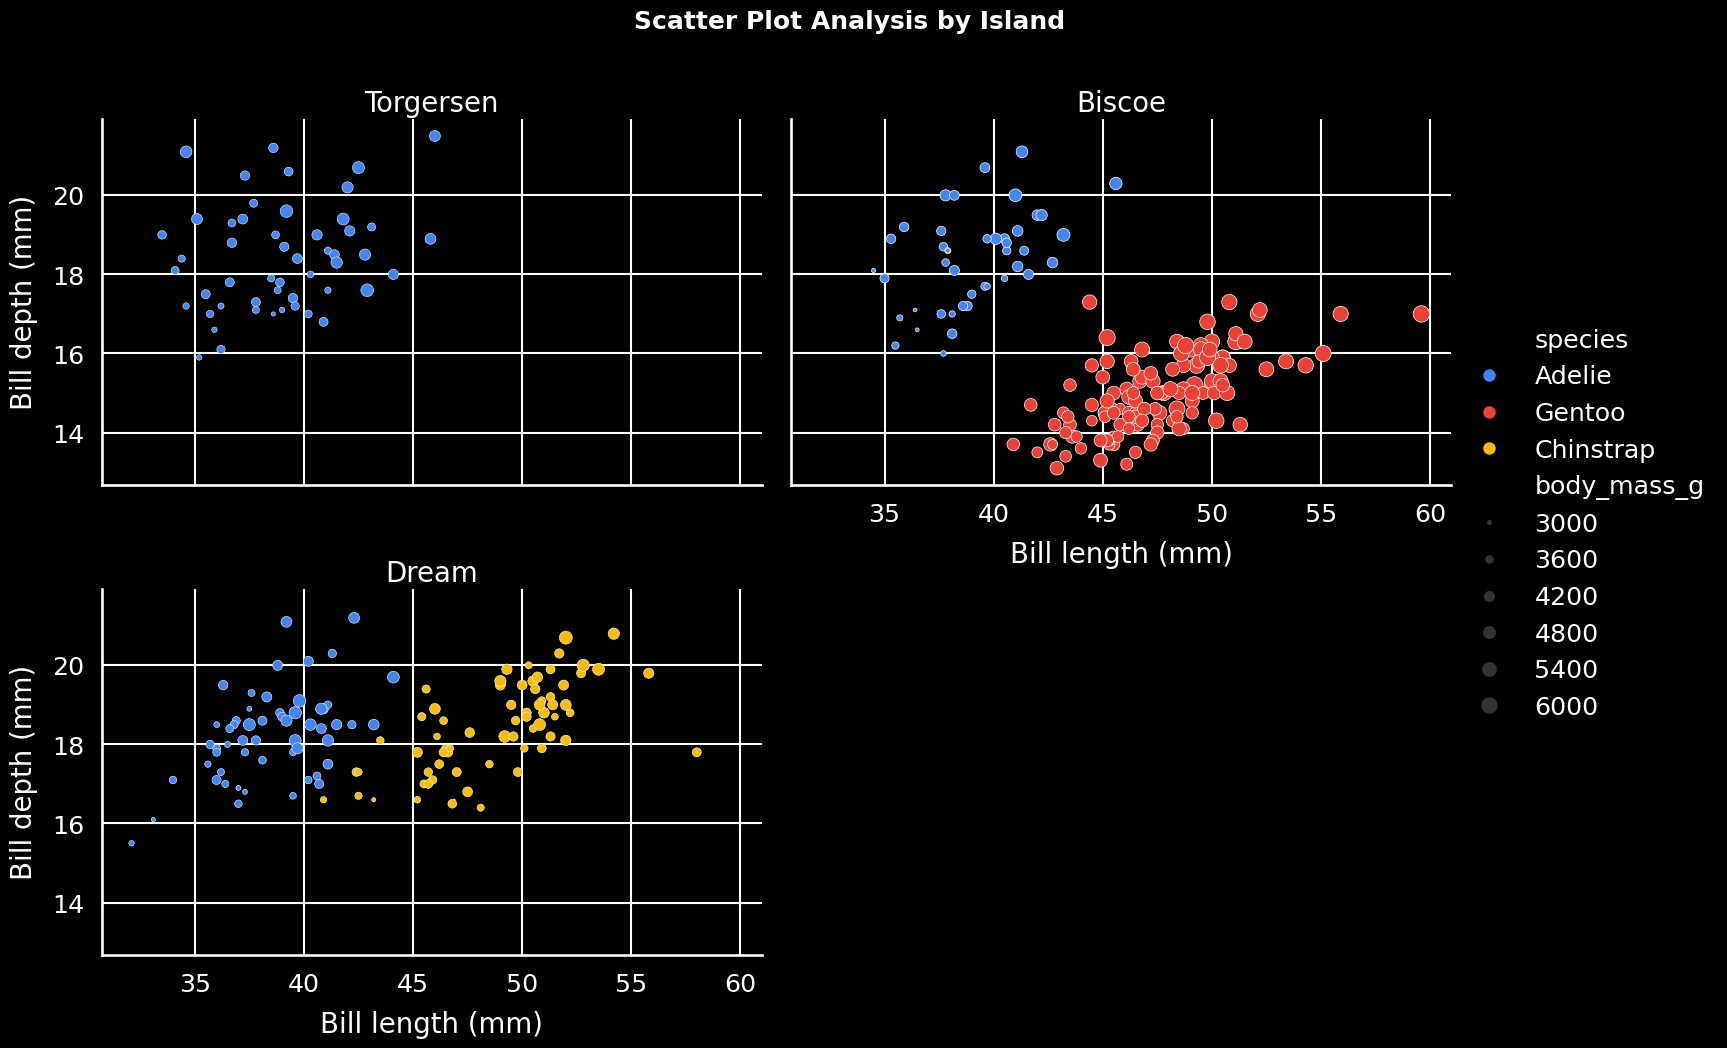

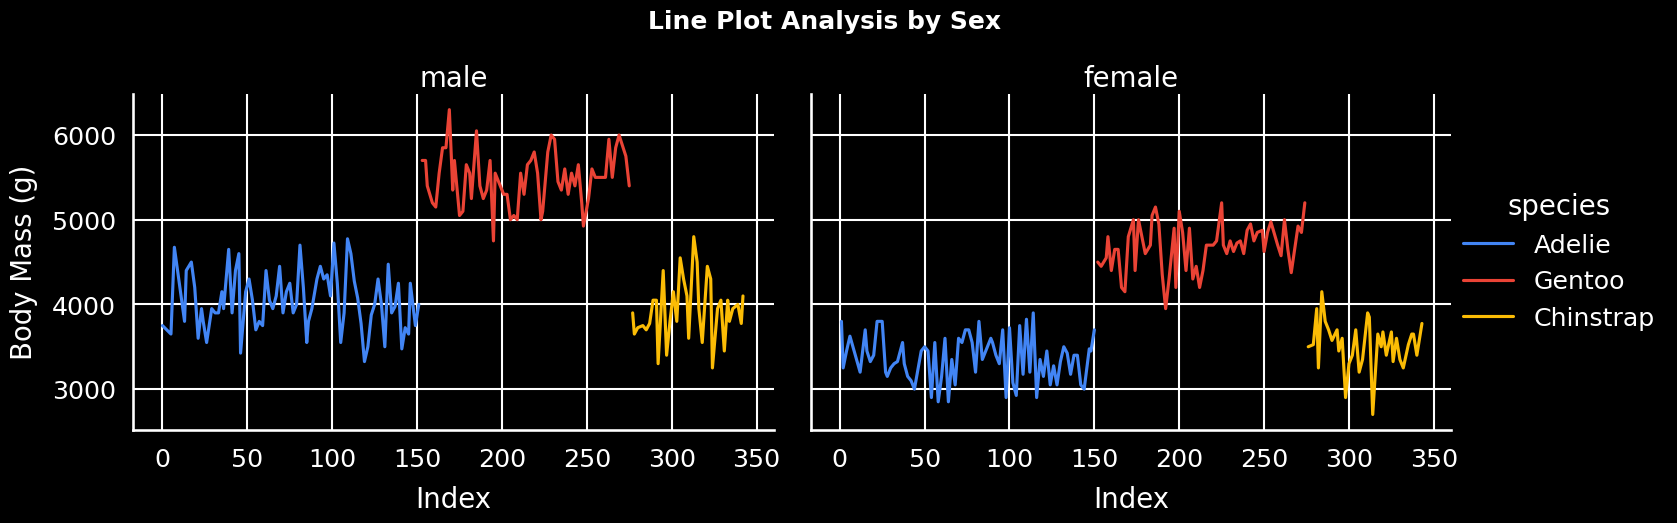

In [11]:
# Scatter plot
g = sns.relplot(data=data, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="scatter", palette=google_three, size="body_mass_g", sizes=(1, 150), height=5, aspect=1.5, col='island', col_wrap=2, row_order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('Scatter Plot Analysis by Island', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Bill depth (mm)', labelpad=10)
g.set_xlabels('Bill length (mm)', labelpad=10)

# Line plot
g = sns.relplot(data=data, x=np.arange(data.shape[0]), y="body_mass_g", hue="species", kind="line", palette=google_three, height=5, aspect=1.5, col='sex', col_wrap=2,errorbar='sd')
g.set_titles('{col_name}')
g.figure.suptitle('Line Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Body Mass (g)', labelpad=10)
g.set_xlabels('Index', labelpad=10)

#### Cat plot

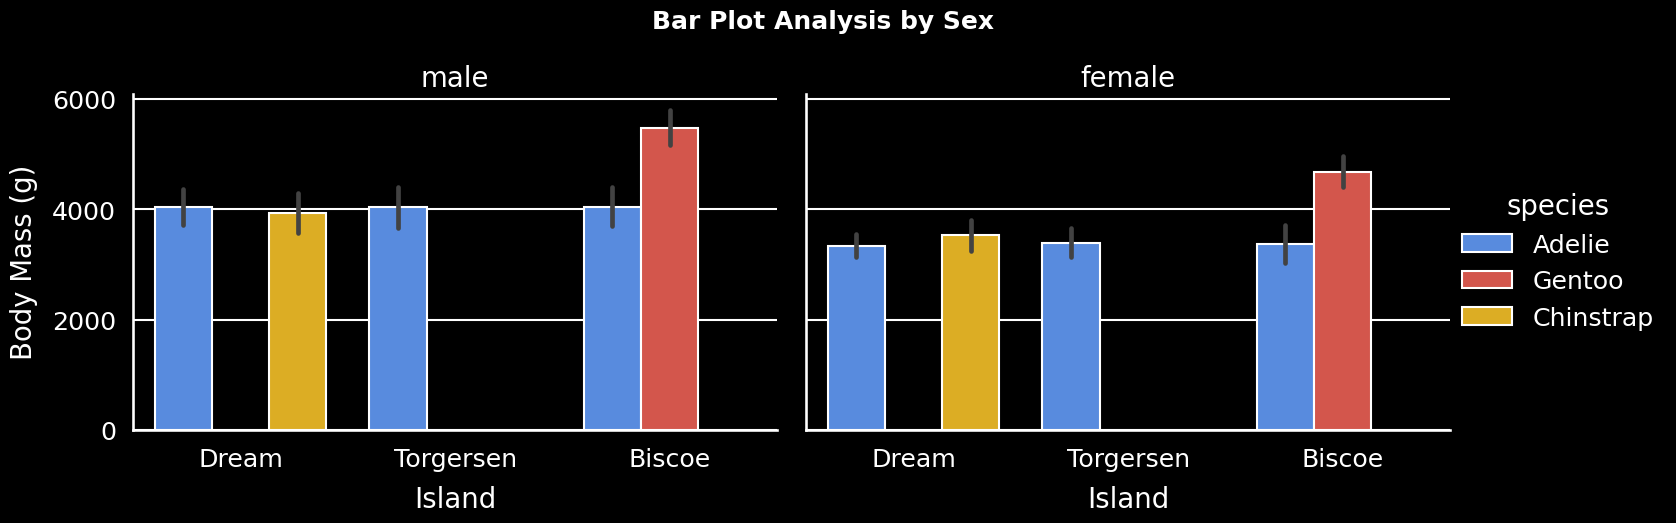

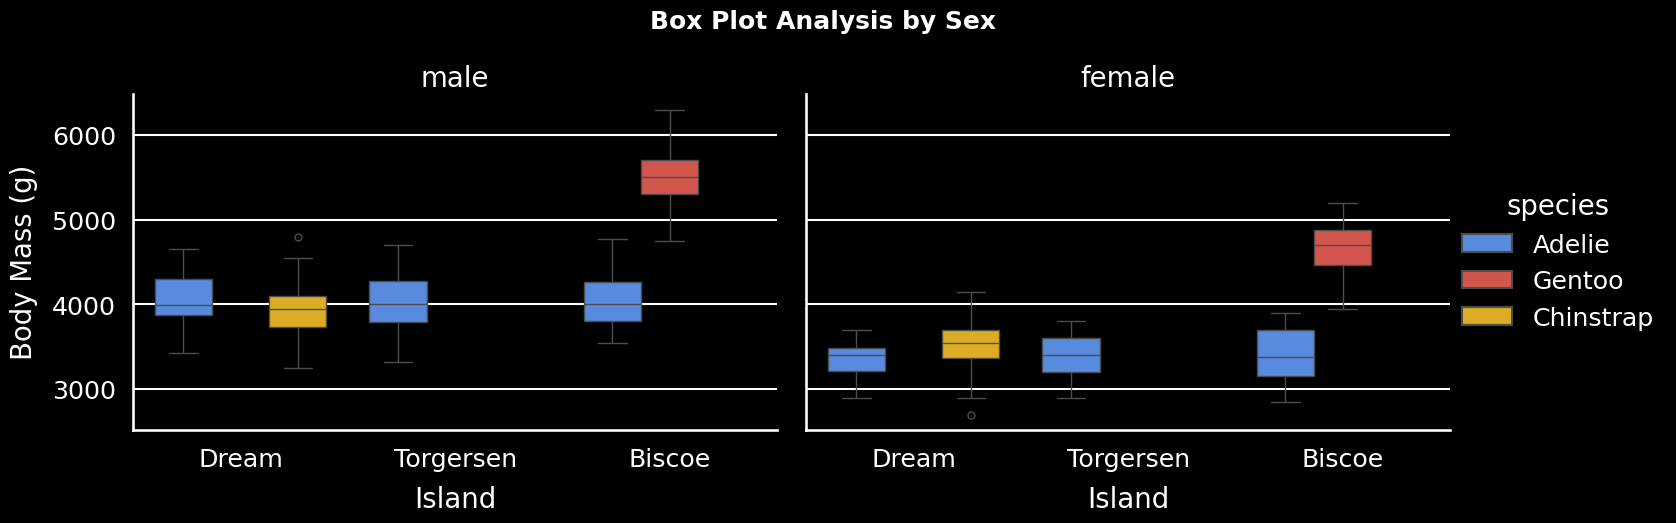

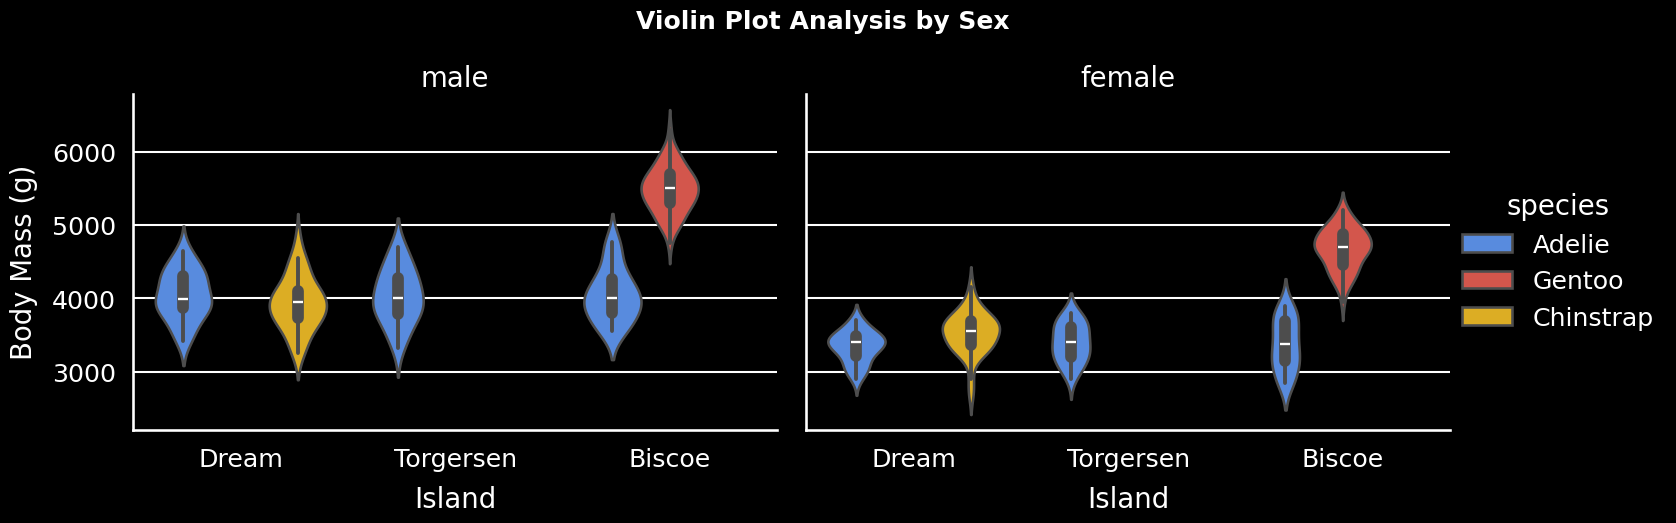

In [12]:
# Bar plot

g = sns.catplot(data=data, x='island', y='body_mass_g', kind='bar', errorbar='sd', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('Bar Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Body Mass (g)', labelpad=10)
g.set_xlabels('Island', labelpad=10)

# Box plot
h = sns.catplot(data=data, x='island', y='body_mass_g', kind='box', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
h.set_titles('{col_name}')
h.figure.suptitle('Box Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
h.set_ylabels('Body Mass (g)', labelpad=10)
h.set_xlabels('Island', labelpad=10)

# Violin plot
h = sns.catplot(data=data, x='island', y='body_mass_g', kind='violin', hue='species', palette=google_three, col='sex', col_wrap=2, height=5, aspect=1.5, order=['Dream', 'Torgersen', 'Biscoe'])
h.set_titles('{col_name}')
h.figure.suptitle('Violin Plot Analysis by Sex', fontsize=18, fontweight='bold', y=1.05)
h.set_ylabels('Body Mass (g)', labelpad=10)
h.set_xlabels('Island', labelpad=10)


#### Displot

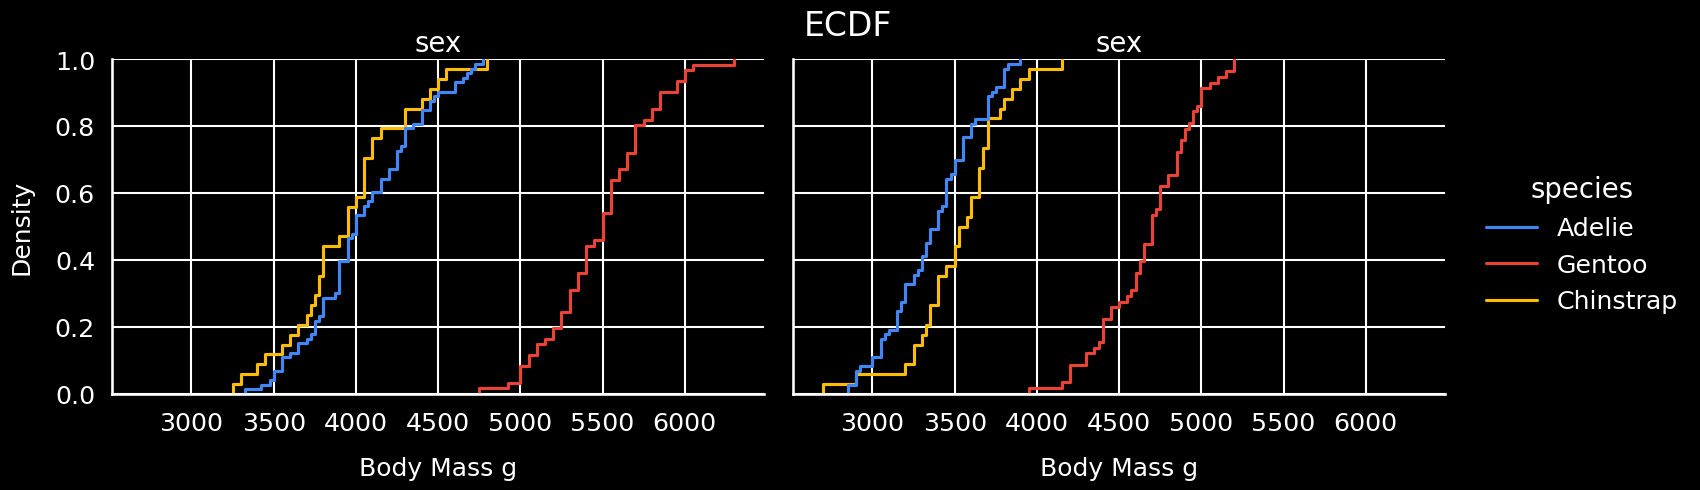

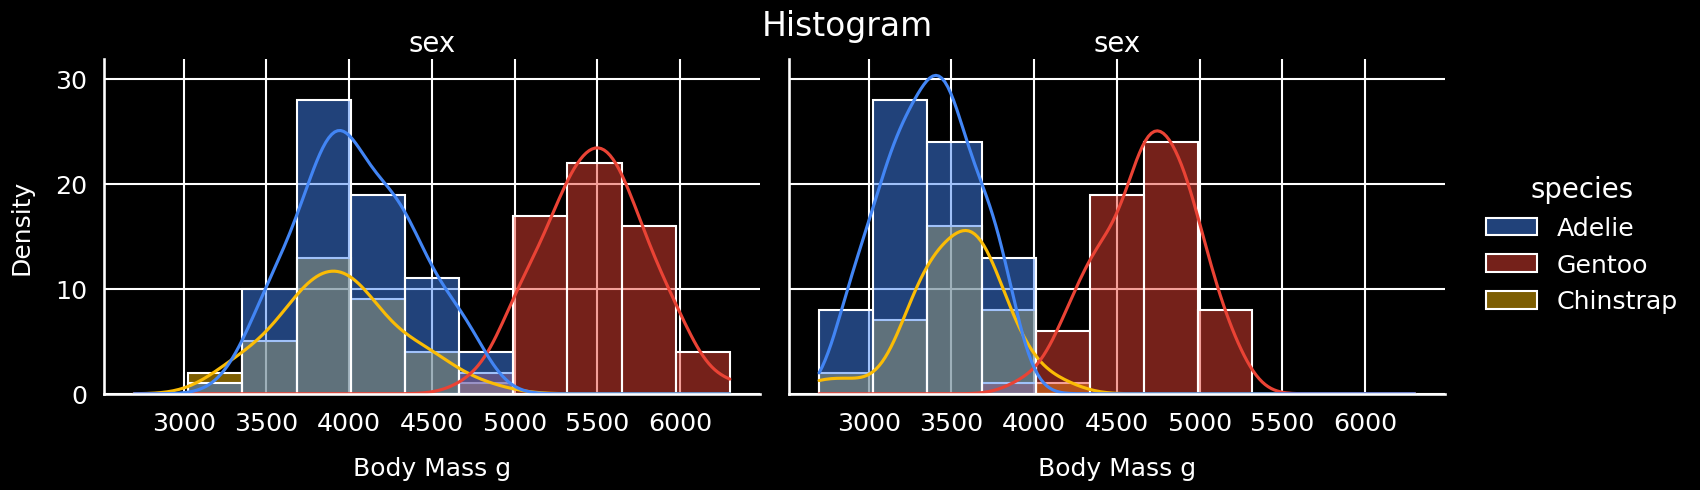

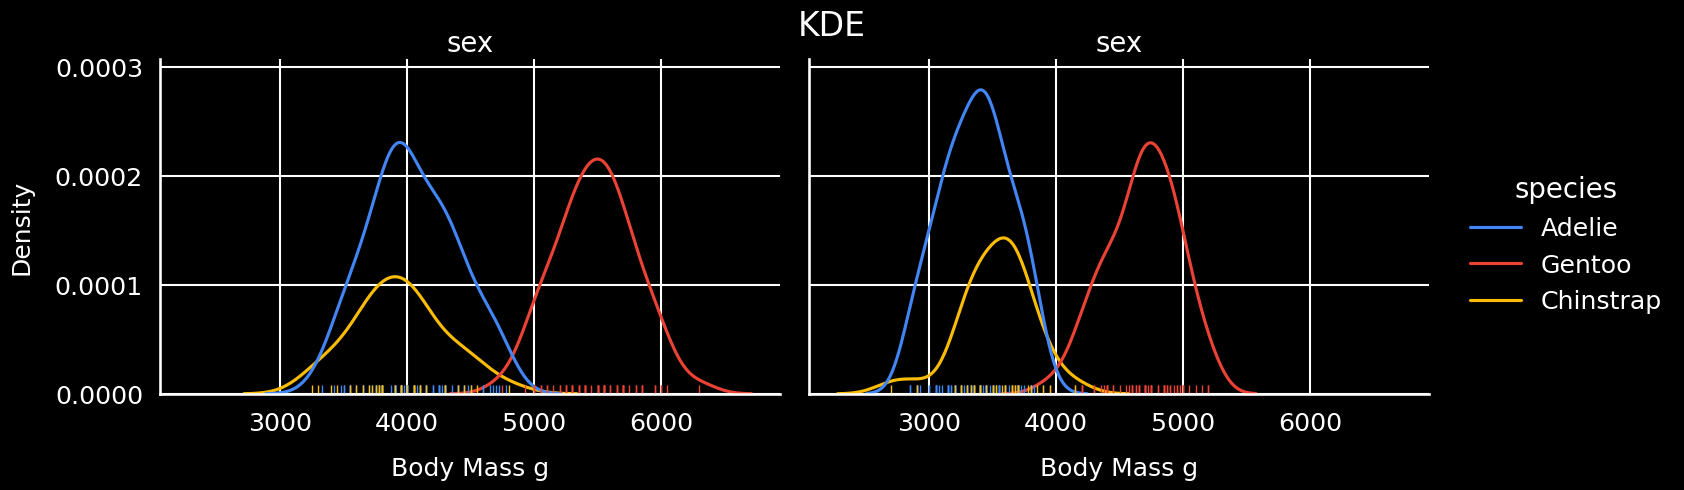

In [13]:
# ECDF
j = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='ecdf', legend=True, col='sex', col_wrap=2, aspect=1.5)
j.set_titles('sex')
j.figure.suptitle('ECDF')
j.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
j.set_ylabels('Density', labelpad=15, fontsize=18)

# Histogram
k = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='hist', legend=True, col='sex', col_wrap=2, aspect=1.5, kde=True)
k.set_titles('sex')
k.figure.suptitle('Histogram')
k.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
k.set_ylabels('Density', labelpad=15, fontsize=18)

# KDE
h = sns.displot(data=data, x='body_mass_g', hue='species', palette=google_three, kind='kde', legend=True, col='sex', col_wrap=2, aspect=1.5, rug=True)
h.set_titles('sex')
h.figure.suptitle('KDE')
h.set_xlabels('Body Mass g', labelpad=15, fontsize=18)
h.set_ylabels('Density', labelpad=15, fontsize=18)

#### Lmplot

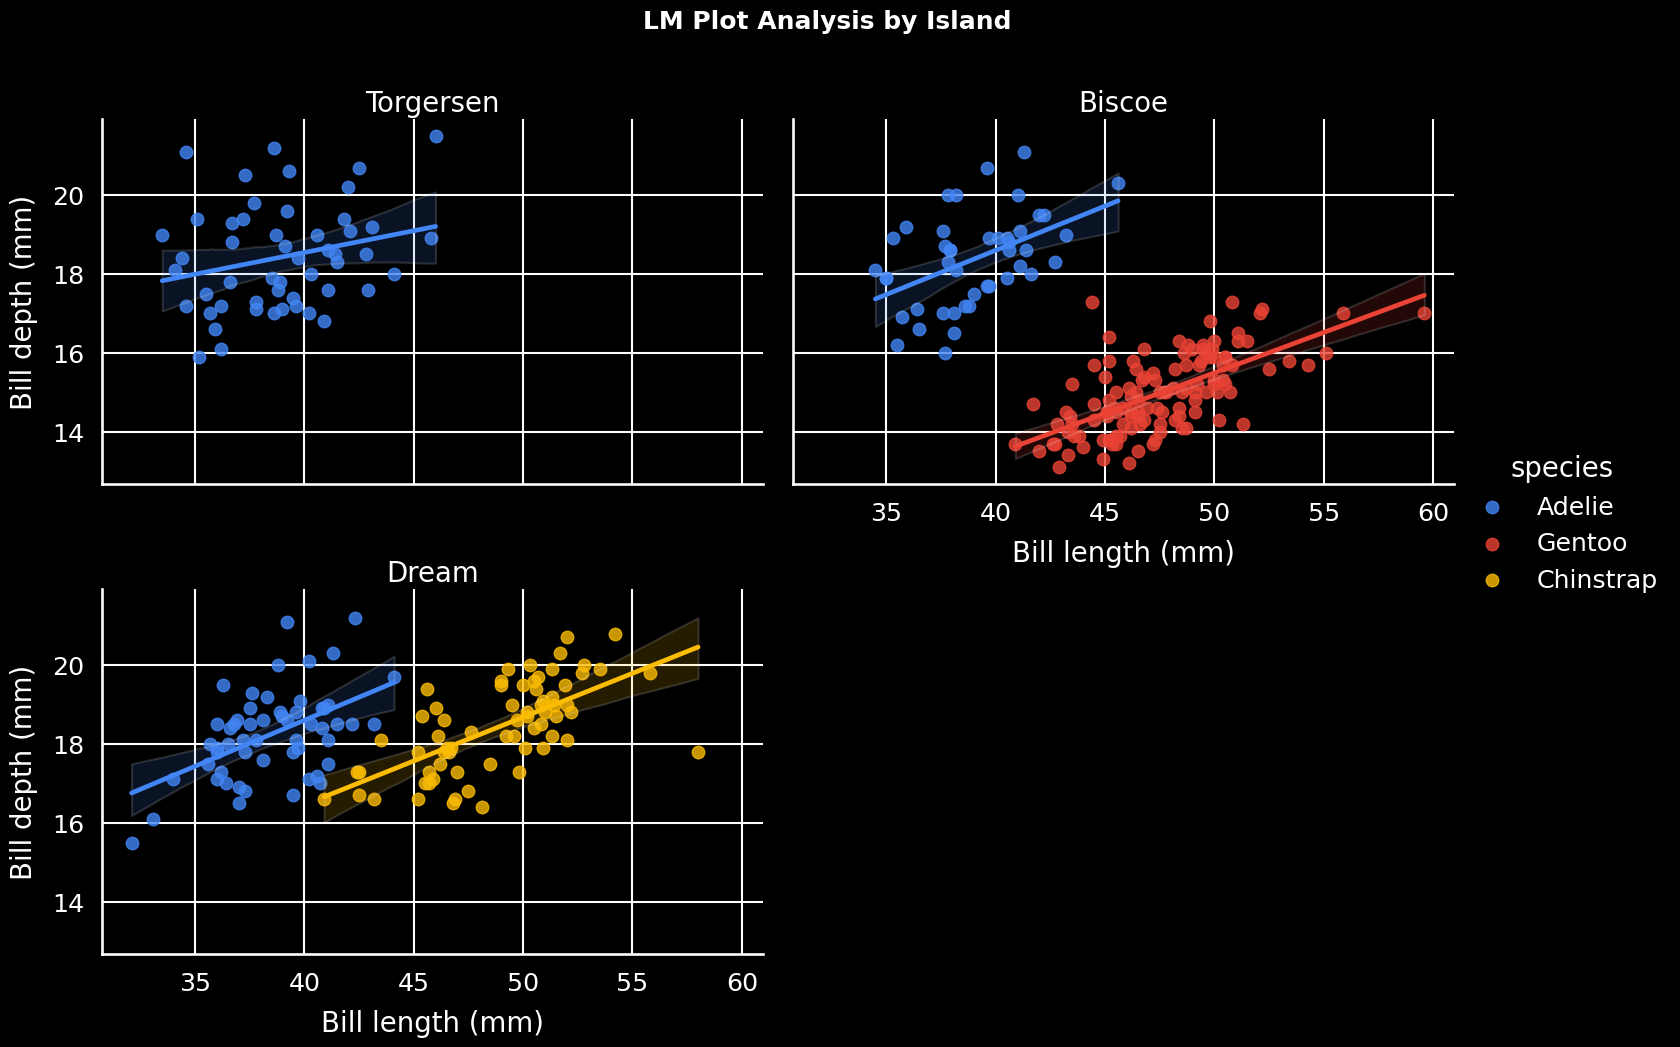

In [16]:
g = sns.lmplot(data=data, x="bill_length_mm", y="bill_depth_mm", hue="species", palette=google_three, aspect=1.5, col='island', col_wrap=2, row_order=['Dream', 'Torgersen', 'Biscoe'])
g.set_titles('{col_name}')
g.figure.suptitle('LM Plot Analysis by Island', fontsize=18, fontweight='bold', y=1.05)
g.set_ylabels('Bill depth (mm)', labelpad=10)
g.set_xlabels('Bill length (mm)', labelpad=10)

### Grid

#### FacetGrid

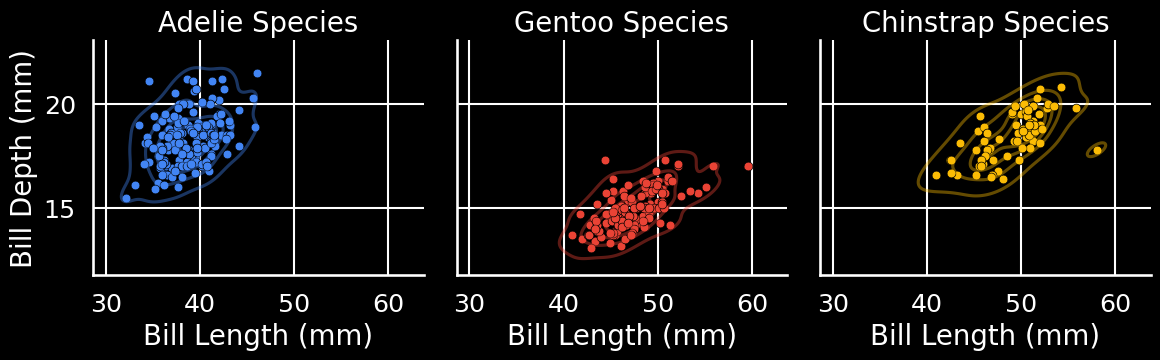

In [17]:
g = sns.FacetGrid(data, col="species", hue="species", height=4)

# 2. LAYER 1: The Contour Map (KDE)
# alpha=0.4 makes the contours slightly transparent so they don't overpower the points
# levels=5 limits the number of rings drawn
g.map(sns.kdeplot, "bill_length_mm", "bill_depth_mm", alpha=0.4, levels=5)

# 3. LAYER 2: The Data Points (Scatterplot)
# edgecolor="black" adds a tiny border to the dots so they pop against the contour lines
# s=40 makes the dots a bit larger
g.map(sns.scatterplot, "bill_length_mm", "bill_depth_mm", edgecolor="black", s=40)

# Clean up
g.set_titles(col_template="{col_name} Species")
g.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
g.tight_layout()

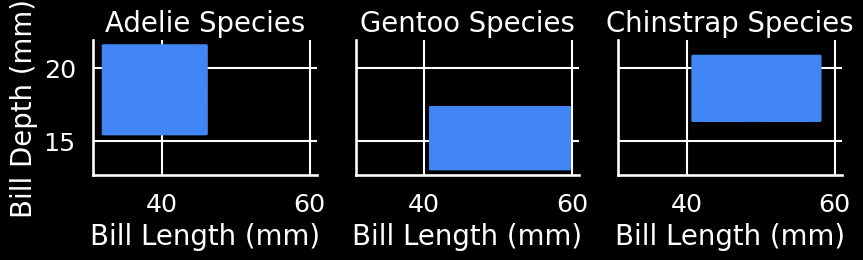

In [20]:
g = sns.FacetGrid(data, col="species")
# Mapping a standard Matplotlib hexbin plot instead of a Seaborn plot
g.map(plt.hexbin, "bill_length_mm", "bill_depth_mm", gridsize=85, cmap="Blues")
g.set_titles(col_template="{col_name} Species")
g.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
# sns.despine()
g.tight_layout()

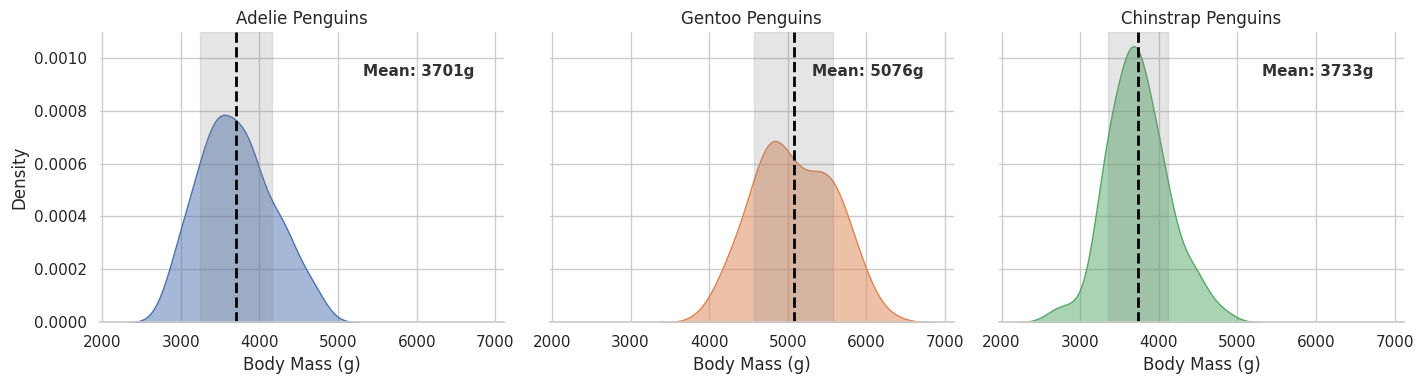

In [21]:
# 1. DEFINE YOUR CUSTOM FUNCTION
# This function will be run individually for every square in the grid
def plot_stats_distribution(x, **kwargs):
    # Get the color Seaborn wants to use for this specific category
    color = kwargs.get("color")

    # Draw the base density plot
    sns.kdeplot(x, fill=True, color=color, alpha=0.5)

    # Calculate our dynamic statistics
    mean_val = np.mean(x)
    std_val = np.std(x)

    # Grab the specific Matplotlib axis we are currently drawing on
    ax = plt.gca()

    # A. Draw a thick dashed line for the Mean
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=2)

    # B. Shade the area representing +/- 1 Standard Deviation
    ax.axvspan(mean_val - std_val, mean_val + std_val, color="gray", alpha=0.2)

    # C. Write the exact mean value as text on the plot
    # transform=ax.transAxes lets us place the text relative to the box dimensions (0 to 1)
    # instead of guessing where the text should go based on the data coordinates
    ax.text(0.65, 0.85, f"Mean: {mean_val:.0f}g", transform=ax.transAxes,
            fontsize=11, fontweight="bold", color="#333333")

# 2. INITIALIZE THE GRID
# We use 'hue' so each species gets its own unique base color passed to our function
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(data, col="species", hue="species", height=4, aspect=1.2)

# 3. MAP THE CUSTOM FUNCTION
# We pass our function name and the column we want to calculate (body_mass_g)
g.map(plot_stats_distribution, "body_mass_g")

# 4. CLEAN UP
g.set_titles(col_template="{col_name} Penguins")
g.set_axis_labels("Body Mass (g)", "Density")

# sns.despine(left=True) is a nice touch that removes the solid Y-axis line
# when you already have horizontal gridlines
sns.despine(left=True)
g.tight_layout()

plt.show()

#### Jointgrid

Text(0.5, 0.98, 'Jointplot - Scatter')

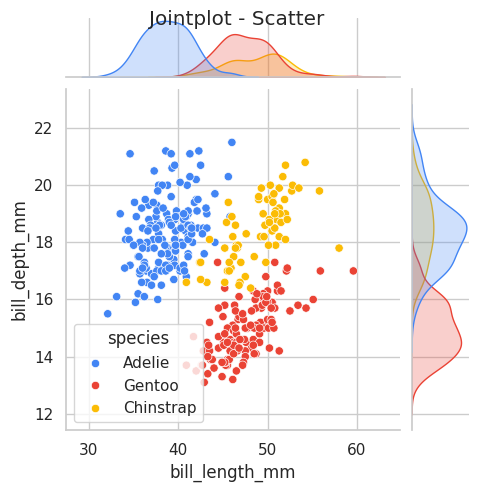

In [22]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', hue='species', kind='scatter', height=5, legend=True, palette=google_three)
x.figure.suptitle('Jointplot - Scatter')

Text(0.5, 0.98, 'Jointplot - Histogram')

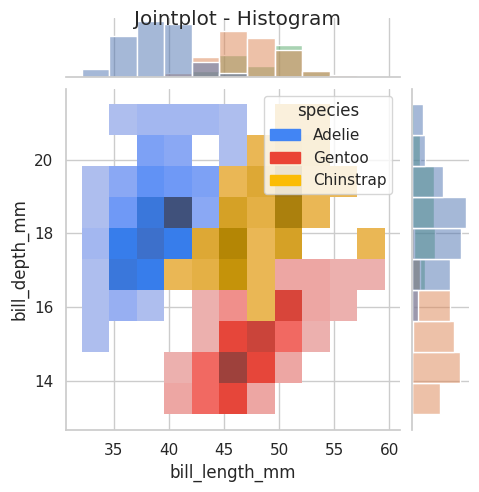

In [23]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', hue='species', kind='hist', height=5, legend=True, palette=google_three)
x.figure.suptitle('Jointplot - Histogram')

Text(0.5, 0.98, 'Jointplot - KDE 2D')

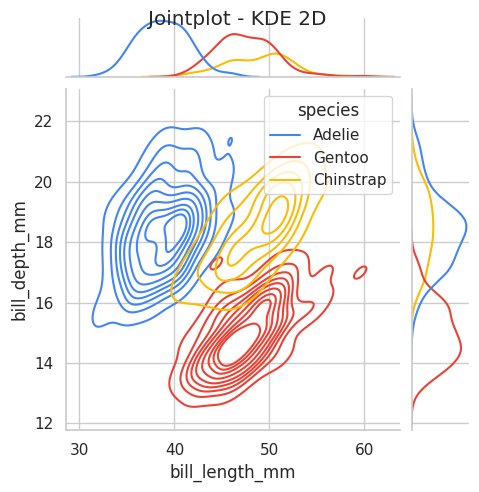

In [24]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', hue='species', kind='kde', height=5, legend=True, palette=google_three)
x.figure.suptitle('Jointplot - KDE 2D')

Text(0.5, 0.98, 'Jointplot - Regression')

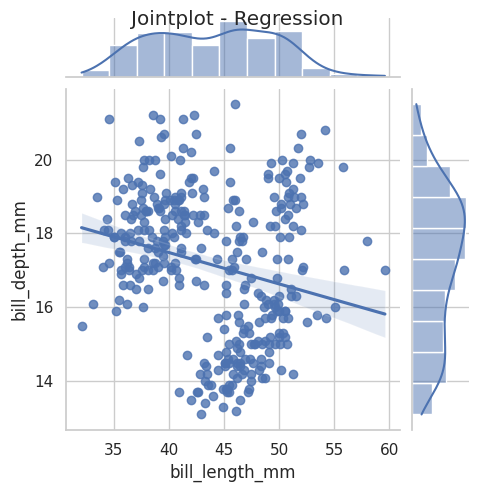

In [25]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', kind='reg', height=5, palette=google_three)
x.figure.suptitle('Jointplot - Regression')

Text(0.5, 0.98, 'Jointplot - Residuals')

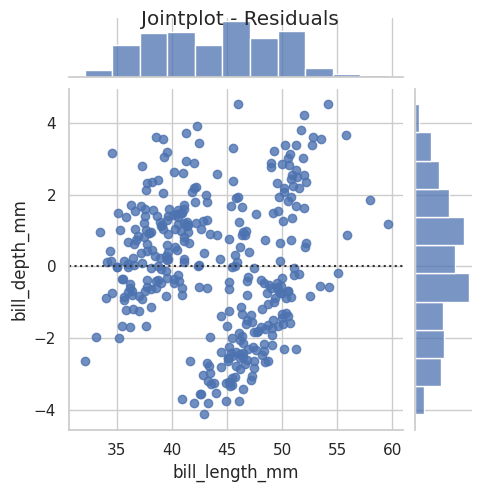

In [26]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', kind='resid', height=5, palette=google_three)
x.figure.suptitle('Jointplot - Residuals')

Text(0.5, 0.98, 'Jointplot - Regression')

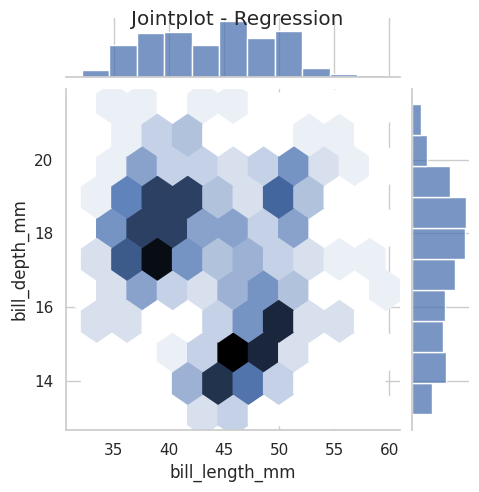

In [27]:
x = sns.jointplot(data, x='bill_length_mm', y='bill_depth_mm', kind='hex', height=5, palette=google_three)
x.figure.suptitle('Jointplot - Regression')

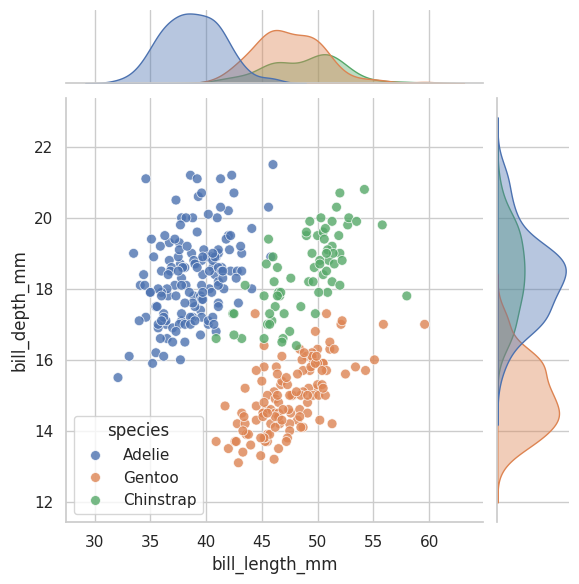

In [28]:
# 1. INITIALIZE: Create the empty engine
# Notice we define the X and Y data right at the start
g = sns.JointGrid(data=data, x="bill_length_mm", y="bill_depth_mm", hue="species")

# 2. MAP THE JOINT (Center Plot)
# Put a scatterplot in the big center square
g.plot_joint(sns.scatterplot, s=50, alpha=0.8)

# 3. MAP THE MARGINALS (Top and Right Plots)
# Put filled density curves on the edges
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.4)

plt.show()

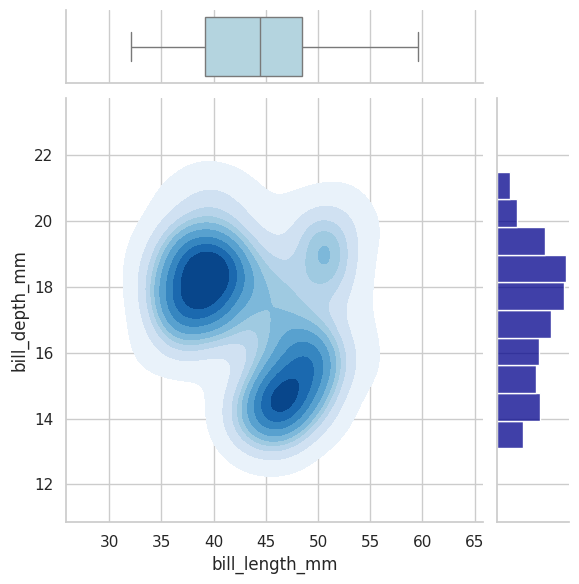

In [29]:
# 1. INITIALIZE
g = sns.JointGrid(data, x="bill_length_mm", y="bill_depth_mm")

# 2. DRAW CENTER
sns.kdeplot(data, x="bill_length_mm", y="bill_depth_mm",
            fill=True, cmap="Blues", ax=g.ax_joint)

# 3. DRAW TOP MARGIN (X-axis)
# We pass our specific top axis to the ax= parameter
sns.boxplot(data, x="bill_length_mm", color="lightblue", ax=g.ax_marg_x)

# 4. DRAW RIGHT MARGIN (Y-axis)
# We pass our specific right axis to the ax= parameter
sns.histplot(data=data, y="bill_depth_mm", color="darkblue", ax=g.ax_marg_y)

# Remove the extra axes lines for a cleaner look
sns.despine()

plt.show()

#### Pairgrid

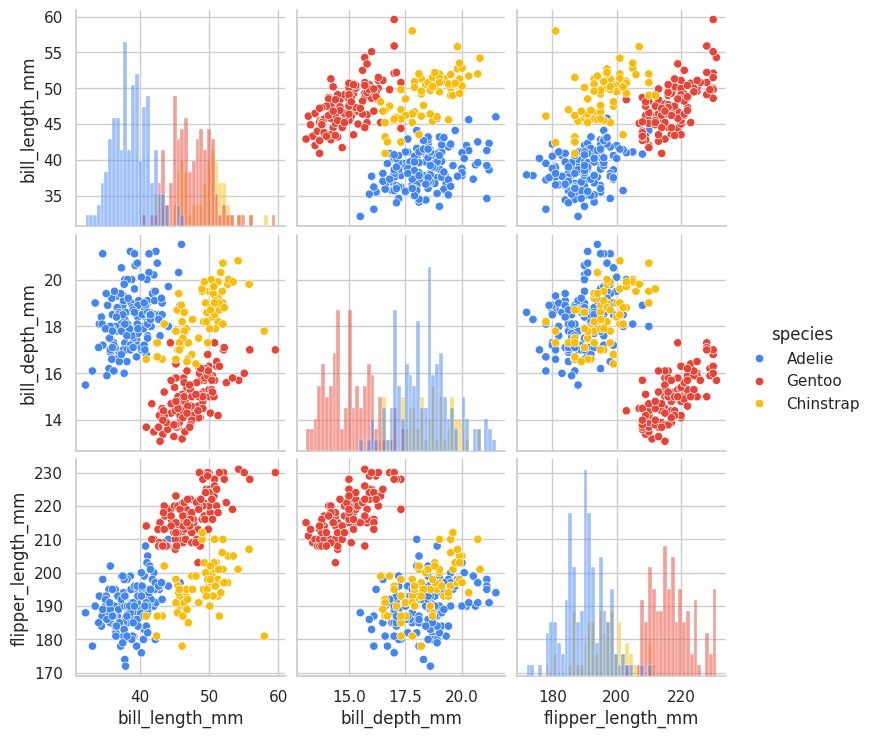

In [30]:
cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

# The Wrapper
sns.pairplot(data, vars=cols, hue="species", kind="scatter", diag_kind="hist", diag_kws={"bins": 50}, palette=google_three)
plt.show()

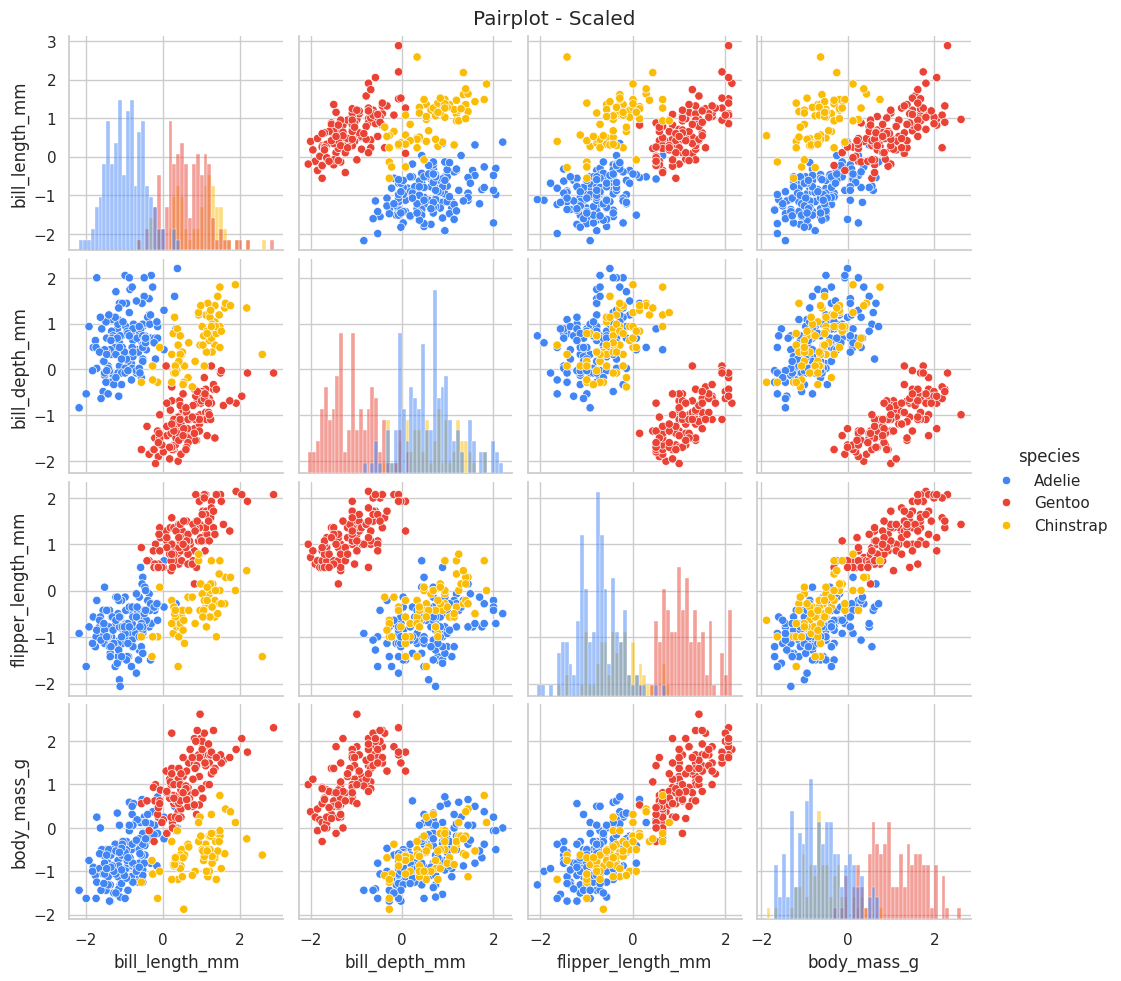

In [31]:
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[num_features])
scaled_data = pd.DataFrame(scaled_data, columns=num_features)
scaled_data['species'] = data['species']
scaled_data.dropna(inplace=True)
g = sns.pairplot(data=scaled_data, hue='species', vars=num_features, kind="scatter", diag_kind="hist", diag_kws={"bins": 50}, palette=google_three)
g.figure.suptitle('Pairplot - Scaled')
g.tight_layout()
plt.show()

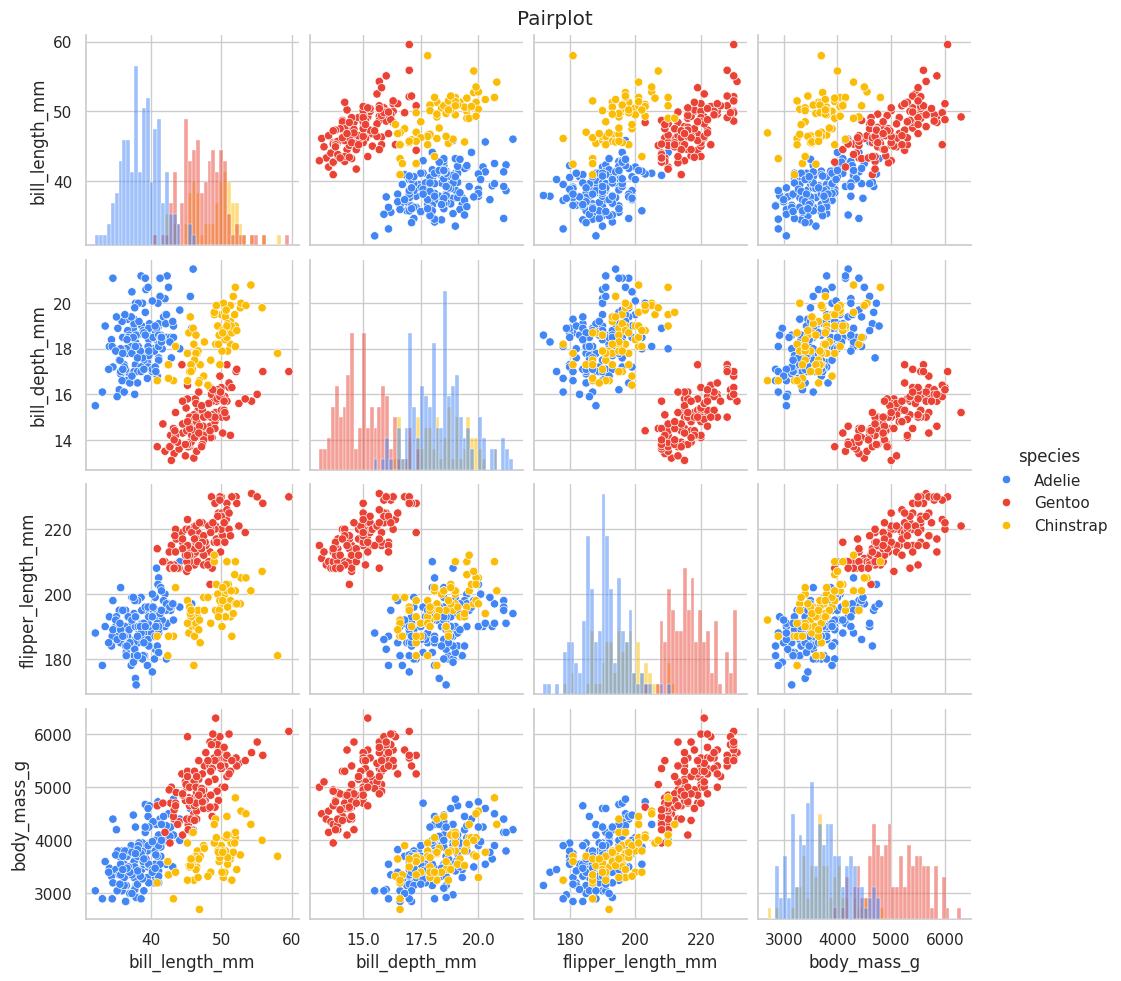

In [32]:
g = sns.pairplot(data=data, hue='species', vars=num_features, kind="scatter", diag_kind="hist", diag_kws={"bins": 50}, palette=google_three)
g.figure.suptitle('Pairplot')
g.tight_layout()
plt.show()

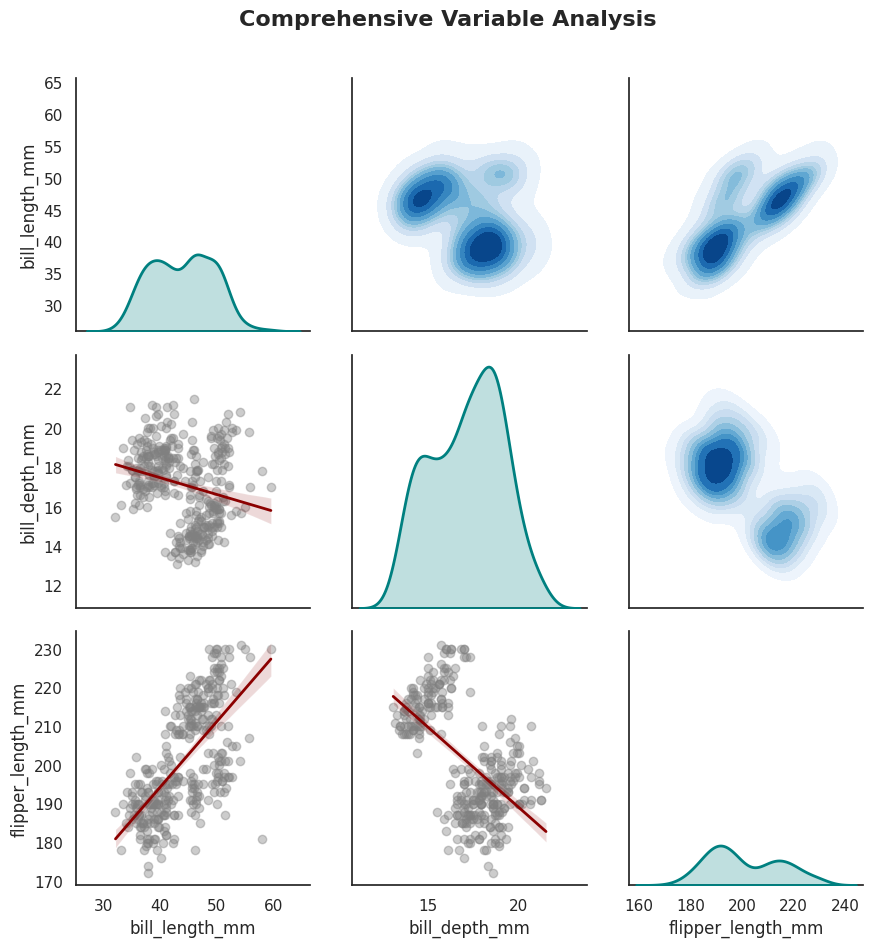

In [33]:
# Select the numeric variables to compare
variables = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

# Set a clean, white background
sns.set_theme(style="white")

# 1. INITIALIZE THE ENGINE
g = sns.PairGrid(data, vars=variables, height=3)

# 2. MAP THE DIAGONAL (1D Distributions)
# We use a filled density curve with a bold line
g.map_diag(sns.kdeplot, fill=True, color="teal", linewidth=2)

# 3. MAP THE LOWER TRIANGLE (Trend Analysis)
# We map sns.regplot. Notice how we pass dictionaries to customize
# the scatter dots (gray/transparent) and the trend line (dark red) separately!
g.map_lower(
    sns.regplot,
    scatter_kws={"alpha": 0.4, "color": "gray"},
    line_kws={"color": "darkred", "linewidth": 2}
)

# 4. MAP THE UPPER TRIANGLE (Concentration Hotspots)
# We map a 2D KDE contour map. thresh=0.05 prevents it from drawing
# contours way out into the empty white space.
g.map_upper(sns.kdeplot, cmap="Blues", fill=True, thresh=0.05)

# 5. FINAL POLISH
# Add a master title. y=1.05 pushes it slightly up so it doesn't overlap the top row.
g.figure.suptitle("Comprehensive Variable Analysis", y=1.05, fontsize=16, fontweight="bold")

plt.show()

#### Clustergrid

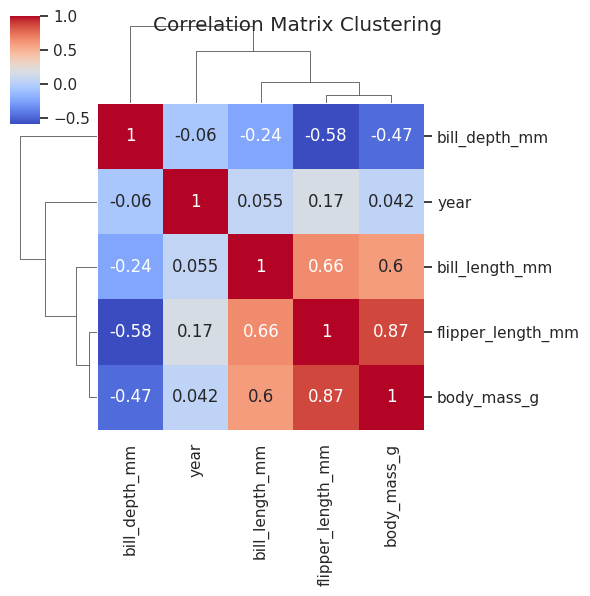

In [35]:


# 1. Prepare the Data
# Clustermaps require purely numeric data in a matrix format
numeric_data = data.select_dtypes(include='number')
correlation_matrix = numeric_data.corr()

# 2. The Magic Wrapper
# annot=True writes the exact correlation numbers inside the boxes
# cmap="coolwarm" gives us a classic blue (negative) to red (positive) scale
g = sns.clustermap(correlation_matrix, annot=True, cmap="coolwarm", figsize=(6, 6))
g.figure.suptitle('Correlation Matrix Clustering')
plt.show()

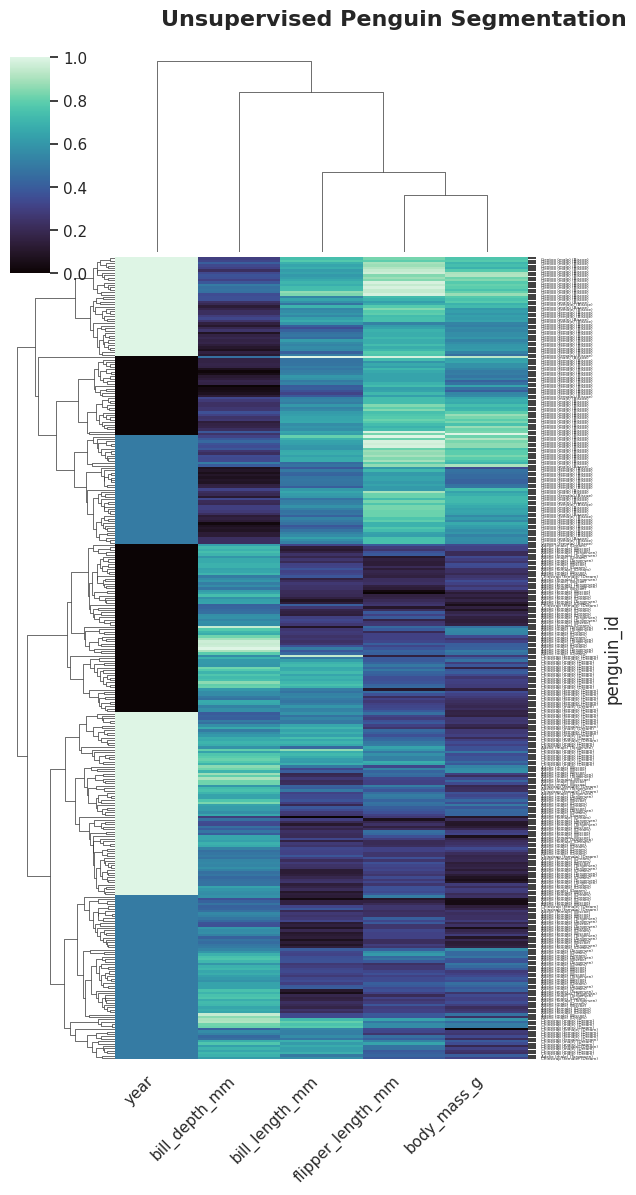

In [37]:

# 2. THE TRICK: Create a custom label for each row
# We combine species and sex so we know exactly who is in each cluster
data['penguin_id'] = data['species'] + " (" + data['sex'] + ")" + " (" + data['island'] + ")"

# Set this new column as the actual index of the dataframe
data = data.set_index('penguin_id')
data.dropna(inplace=True)

# 3. Isolate the numerical data
# The math will crash if it tries to calculate the distance between words
raw_measurements = data.select_dtypes(include='number')

# 4. Run the Observation Clustermap
g = sns.clustermap(
    raw_measurements,
    standard_scale=1,    # CRITICAL: Scales the columns (0 to 1) so 5000g doesn't overpower 40mm
    cmap="mako",         # A great dark theme colormap
    figsize=(8, 12),     # Make it tall to accommodate the 333 rows
    yticklabels=True,    # Force it to print our custom index labels
    xticklabels=True
)

# 5. Tweak the aesthetics
# The row labels will be very crowded, so we shrink the font size
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=3)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

# Add a title to the whole figureure
g.figure.suptitle("Unsupervised Penguin Segmentation", y=1.02, fontsize=16, fontweight="bold")

plt.show()

# DRAFT

In [ ]:
data.info()

In [ ]:
figure, ax = plt.subplots(figuresize=(10, 10))
sns.boxplot(data=data, x='species', y='body_mass_g', hue='island')

In [ ]:
data.info()

In [ ]:
data.corr(numeric_only=True)

In [ ]:
pivot_table = pd.pivot_table(data=data, index='species', columns=['sex', 'island'], values='body_mass_g', aggfunc='mean').round(2).fillna(0)
print(pivot_table)

In [ ]:
figure, axes = plt.subplots(2,2, figuresize=(15, 10))

# # Creates a gradient starting from a custom color
# sns.color_palette("light:purple", as_cmap=False)
# sns.color_palette("dark:#33a02c", as_cmap=False)

# Blends two explicit hex codes or color names across a custom step-count
# sns.color_palette("blend:green,red", 10)
# sns.color_palette("deep")       # Default muted theme
# sns.color_palette("muted")      # Brighter, highly rich tones
# sns.color_palette("bright")     # High saturation colors
# sns.color_palette("pastel")     # Soft, washed-out tones
# sns.color_palette("dark")       # Low-luminance, rich colors
# sns.color_palette("colorblind")

#
# sns.set_theme(style="dark")
# sns.set_palette("seismic")
plt.style.use('dark_background')
# sns.set_theme(style="darkgrid")


# 2. Define Google's official brand hex codes
# Blue, Red, Yellow, Green
google_colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]

# 3. Set it globally
sns.set_palette(google_colors)


# Count plot
sns.countplot(data=data, x="species", ax=axes[0, 0], hue='sex', alpha=0.75)
axes[0, 0].set_title('Count plot')
axes[0, 0].set_xlabel('Species')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0, 1], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'], errorbar='sd')
axes[0, 1].set_title('Line plot')
axes[0, 1].set_xlabel('Bill length')
axes[0, 1].set_ylabel('Bill depth')
axes[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Scatter plot
sns.scatterplot(data=data, x='bill_length_mm', y='bill_depth_mm', ax=axes[1, 0], hue='species', hue_order=['Adelie', 'Gentoo', 'Chinstrap'])
axes[1, 0].set_title('Scatter plot')
axes[1, 0].set_xlabel('Bill length')
axes[1, 0].set_ylabel('Bill depth')
axes[1, 0].grid(True, linestyle='--', which='major', axis='both')

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

In [ ]:
adelie['bill_length_mm'].std()

In [ ]:
data.query('species == "Adelie"')['sex'].value_counts()

In [ ]:
data.query('species == "Adelie"')['sex']

In [ ]:
np.vstack([adelie['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45]])

In [ ]:
adelie.query('sex == "male"')

In [ ]:
import matplotlib.pyplot as plt

# X: True numerical vector (Continuous hours of operation)
hours_of_day = [9, 10, 11, 12, 13]

# Y: True numerical vector (Average hourly foot traffic)
avg_customers = [15, 45, 110, 150, 85]

# Plotting the bars
plt.bar(hours_of_day, avg_customers, color='teal', width=0.8)

# Labeling the continuous numerical data
plt.xlabel('Hour of the Day (24-Hour Clock)')
plt.ylabel('Average Customer Count')
plt.title('Hourly Customer Traffic for Staffing Allocation')

# Ste

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
figure, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
figure, ax = plt.subplots()

ax.stairs(y, linewidth=1.5)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [ ]:
adelie_120 = adelie['bill_length_mm'].iloc[0:121].ffill()
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121].ffill()
print(adelie_120)
print(gentoo_120)

In [ ]:
example = adelie_120.values + gentoo_120.values

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = -np.sin(x)

figure, ax = plt.subplots()

# 1. Fill between y1 and y2
ax.fill_between(x, y1, y2, color='blue', alpha=0.3)

# 2. Fill between y2 and y3
ax.fill_between(x, y2, y3, color='orange', alpha=0.3)

# Add lines for context
ax.plot(x, y1, color='blue')
ax.plot(x, y2, color='orange')
ax.plot(x, y3, color='green')

plt.show()


In [ ]:
data.describe()